<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Letter_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

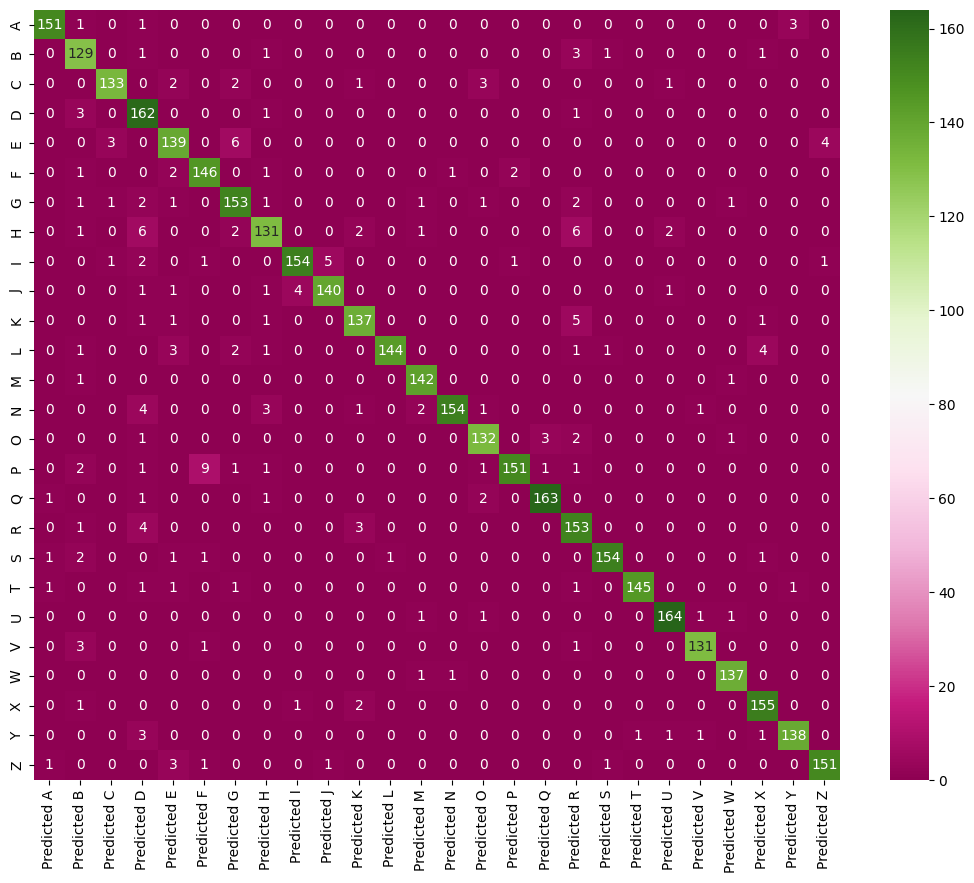

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('/content/letter-recognition.csv')
df.head()

df.shape

df.isna().sum()

x = df.drop('letter', axis=1)
y = df['letter']

y

x_train = x.iloc[:16000, :]
x_test = x.iloc[16000:, :]
y_train = y.iloc[:16000]
y_test = y.iloc[16000:]

from sklearn.svm import SVC

model = SVC(C=3) # C is the penalty

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

y_pred

model.score(x_test, y_test)

y_grid = pd.DataFrame((np.column_stack([y_test,y_pred])))

y_grid

import string
lab = list(string.ascii_uppercase[0:26])
plab=["Predicted "+ s for s in lab]

from sklearn import metrics
import seaborn as sns

cm = metrics.confusion_matrix(y_test, y_pred,labels=lab)

df_cm = pd.DataFrame(cm, index=[i for i in lab],
                     columns= [i for i in plab])

plt.figure(figsize=(13,10))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='PiYG')
plt.show()